导入数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" 

In [3]:
# 加载数据
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# 数据概况

In [4]:
# 查看前3行
print("\n训练集前3行:")
print(train.head(3))

# 查看数据概况
print("\n训练集信息:")
print(f"行数: {train.shape[0]}, 列数: {train.shape[1]}")


训练集前3行:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck             Name  \
0          0.0        0.0           0.0     0.0     0.0  Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0     Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0    Altark Susent   

   Transported  
0        False  
1         True  
2        False  

训练集信息:
行数: 8693, 列数: 14


In [5]:
print('训练集缺失值:')
print(train.isna().sum())
print('')
print('测试集缺失集:')
print(test.isna().sum())

训练集缺失值:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

测试集缺失集:
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


# 初步探索

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Target distribution')

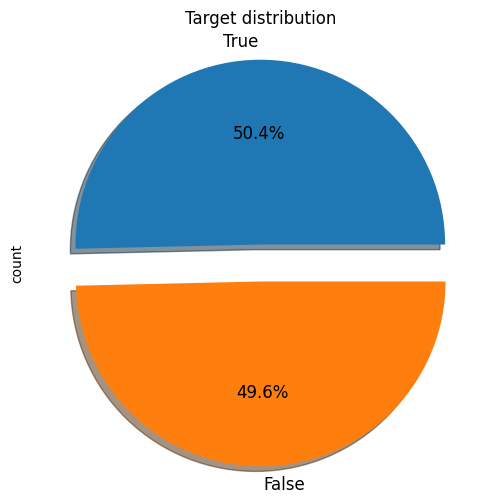

In [6]:
# Figure size
plt.figure(figsize=(6,6))

# transported分布饼图
train['Transported'].value_counts().plot.pie(explode=[0.1,0.1], autopct='%1.1f%%', shadow=True, textprops={'fontsize':12}).set_title("Target distribution")

<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='Age', ylabel='Count'>

Text(0.5, 1.0, 'Age distribution')

Text(0.5, 0, 'Age (years)')

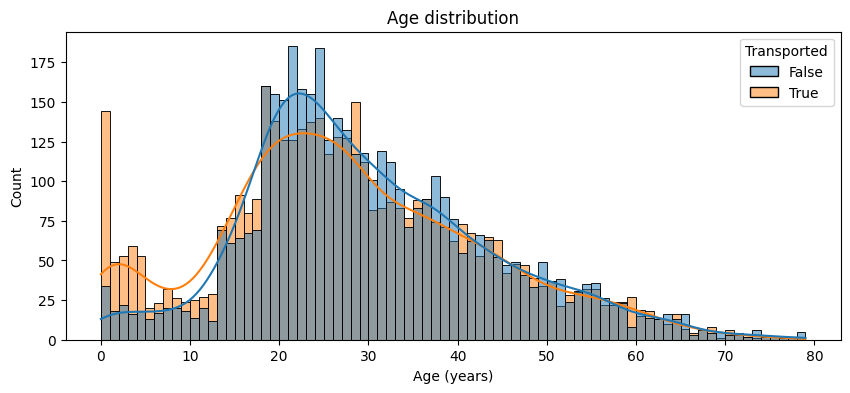

In [7]:
# Figure size
plt.figure(figsize=(10,4))

# 年龄分布直方图
sns.histplot(data=train, x='Age', hue='Transported', binwidth=1, kde=True)
plt.title('Age distribution')
plt.xlabel('Age (years)')

<Axes: xlabel='RoomService', ylabel='Count'>

Text(0.5, 1.0, 'RoomService')

<Axes: xlabel='RoomService', ylabel='Count'>

(0.0, 300.0)

Text(0.5, 1.0, 'RoomService')

...

<Axes: xlabel='VRDeck', ylabel='Count'>

Text(0.5, 1.0, 'VRDeck')

<Axes: xlabel='VRDeck', ylabel='Count'>

(0.0, 300.0)

Text(0.5, 1.0, 'VRDeck')

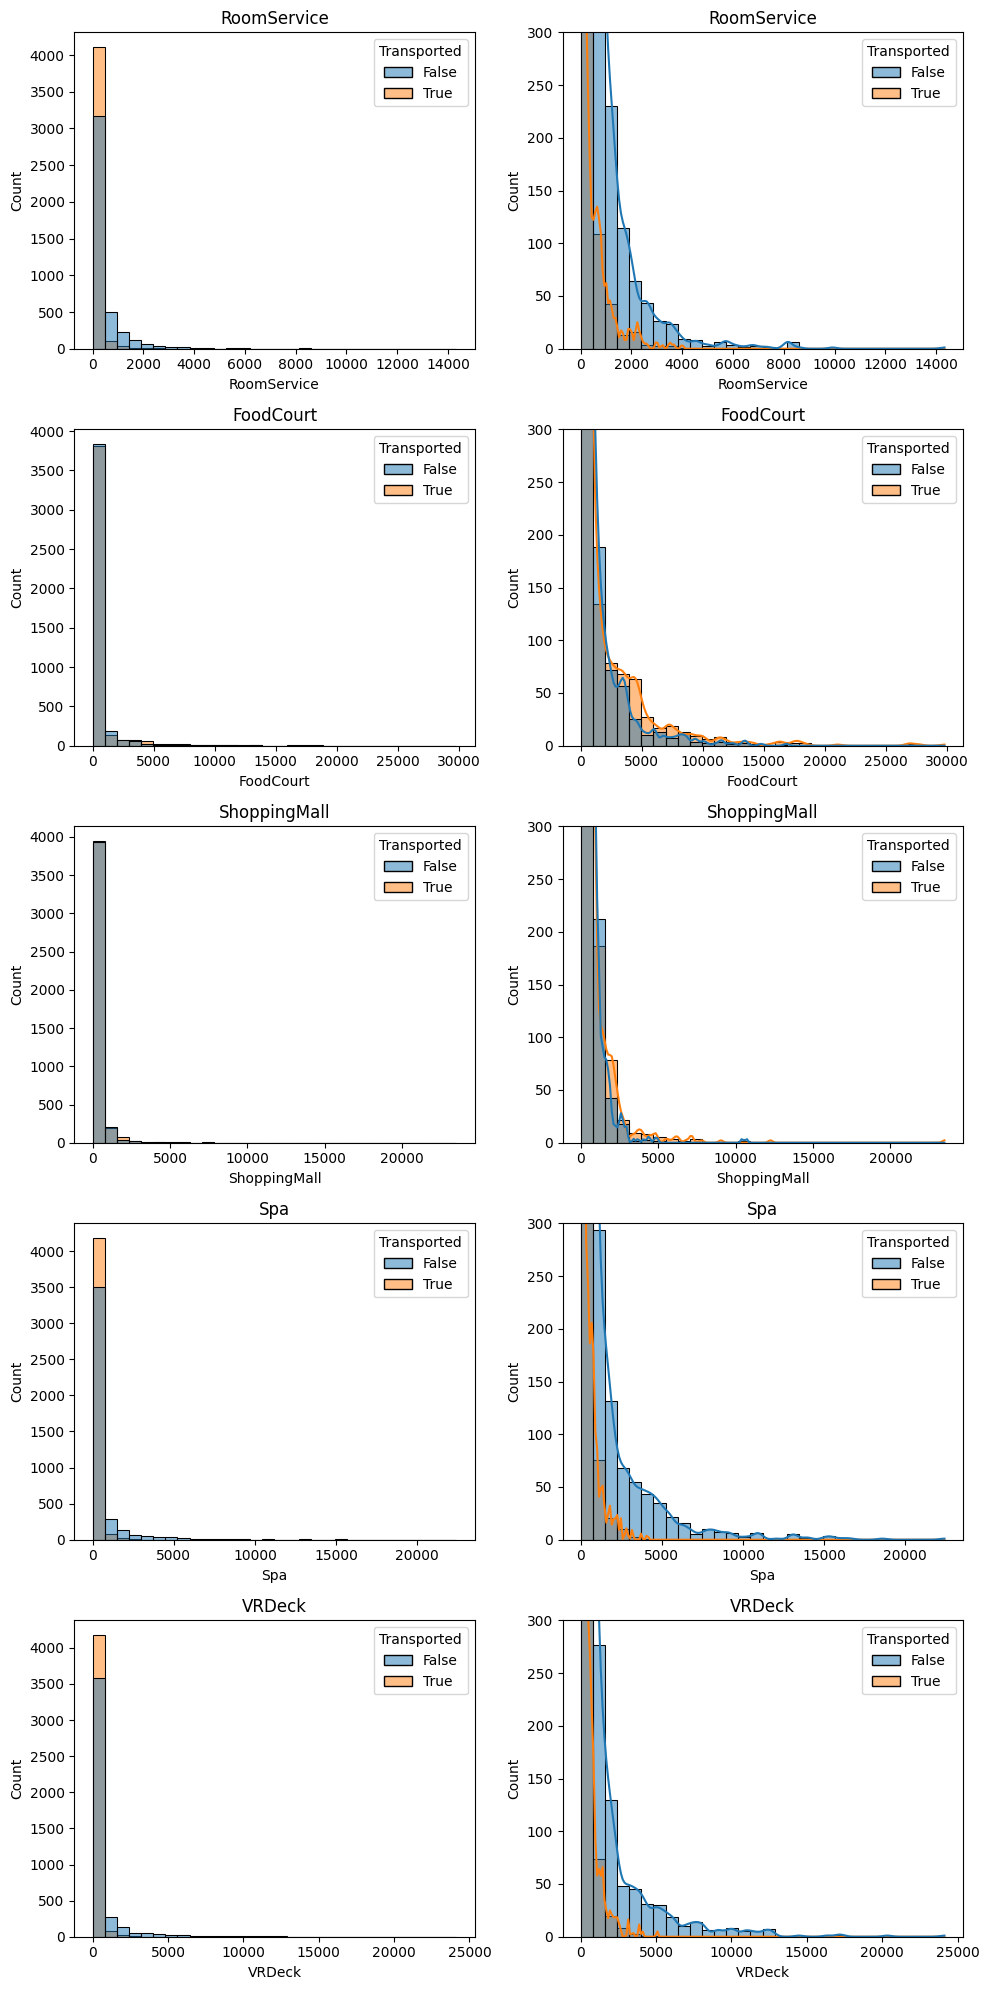

In [8]:
# 各消费字段分析
exp_feats=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Plot expenditure features
fig=plt.figure(figsize=(10,20))
for i, var_name in enumerate(exp_feats):
    #左边单纯统计频数
    ax=fig.add_subplot(5,2,2*i+1)
    sns.histplot(data=train, x=var_name, axes=ax, bins=30, kde=False, hue='Transported')
    ax.set_title(var_name)
    
    # 右边加上核密度曲线
    ax=fig.add_subplot(5,2,2*i+2)
    sns.histplot(data=train, x=var_name, axes=ax, bins=30, kde=True, hue='Transported')
    plt.ylim([0,300])#限制y轴高度，方便观察核密度估计曲线
    ax.set_title(var_name)
fig.tight_layout()  # Improves appearance a bit
plt.show()

<Axes: xlabel='HomePlanet', ylabel='count'>

Text(0.5, 1.0, 'HomePlanet')

<Axes: xlabel='CryoSleep', ylabel='count'>

Text(0.5, 1.0, 'CryoSleep')

<Axes: xlabel='Destination', ylabel='count'>

Text(0.5, 1.0, 'Destination')

<Axes: xlabel='VIP', ylabel='count'>

Text(0.5, 1.0, 'VIP')

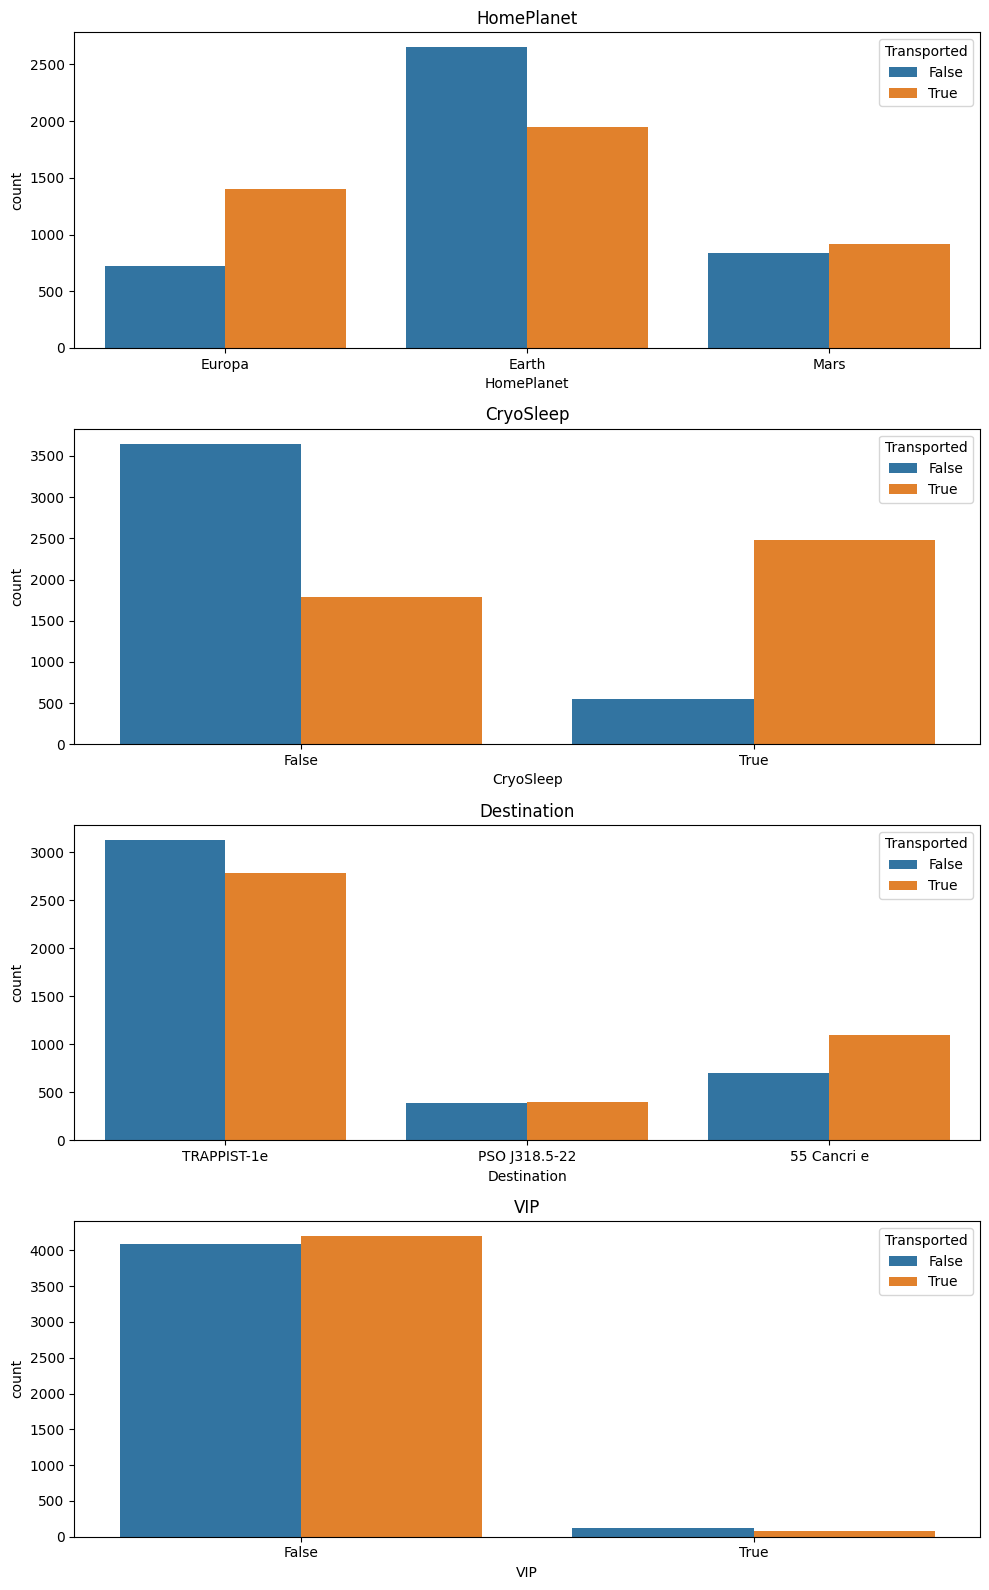

In [9]:
# 名义类特征
cat_feats=['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# 直方图统计频数
fig=plt.figure(figsize=(10,16))
for i, var_name in enumerate(cat_feats):
    ax=fig.add_subplot(4,1,i+1)
    sns.countplot(data=train, x=var_name, axes=ax, hue='Transported')
    ax.set_title(var_name)
fig.tight_layout()  # Improves appearance a bit
plt.show()


缺失值分析

# 进一步探索

## 1.消费

是否消费越多，越容易被传走？或者没有消费的更容易被传走

<Axes: >

<Axes: xlabel='exp_tol', ylabel='Count'>

Text(0.5, 1.0, 'Total expenditure (truncated)')

(0.0, 200.0)

(0.0, 20000.0)

<Axes: >

<Axes: xlabel='No_spending', ylabel='count'>

Text(0.5, 1.0, 'No spending indicator')

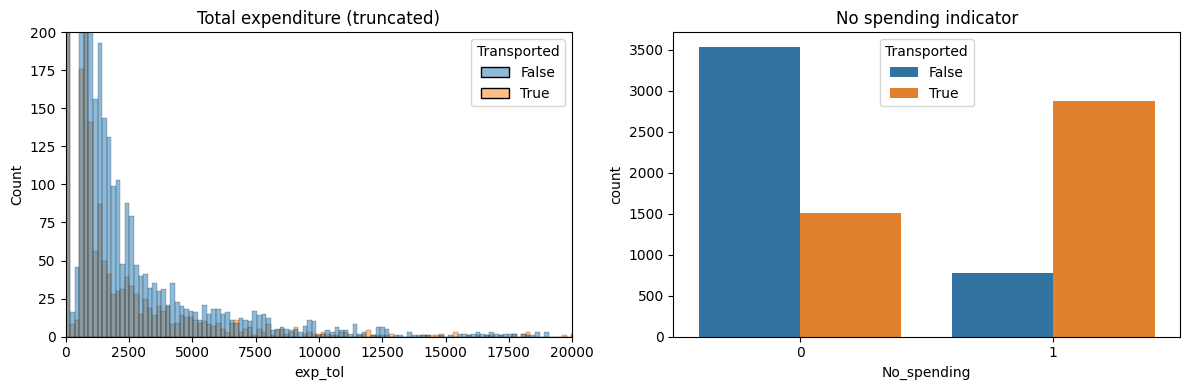

In [10]:
#新增字段“总消费”
train['exp_tol'] = train[exp_feats].sum(axis=1)
test['exp_tol'] = test[exp_feats].sum(axis=1)

fig=plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data=train, x='exp_tol', hue='Transported', bins=200)
plt.title('Total expenditure (truncated)')
plt.ylim([0,200])
plt.xlim([0,20000])

#新增字段是否消费
train['No_spending']=(train['exp_tol']==0).astype(int)
test['No_spending']=(test['exp_tol']==0).astype(int)

plt.subplot(1,2,2)
sns.countplot(data=train, x='No_spending', hue='Transported')
plt.title('No spending indicator')
fig.tight_layout()

## 2.乘客分组

观察乘客id，可以发现前四位是组号，后两位是组内编号.会不会是特定组别更容易被传走

<Figure size 2000x400 with 0 Axes>

<Axes: >

<Axes: xlabel='Group', ylabel='Count'>

Text(0.5, 1.0, 'Group')

<Axes: >

<Axes: xlabel='Group_size', ylabel='count'>

Text(0.5, 1.0, 'Group size')

/home/gyh/Documents/Coding/spaceship-titanic/venv/lib64/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/gyh/Documents/Coding/spaceship-titanic/venv/lib64/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


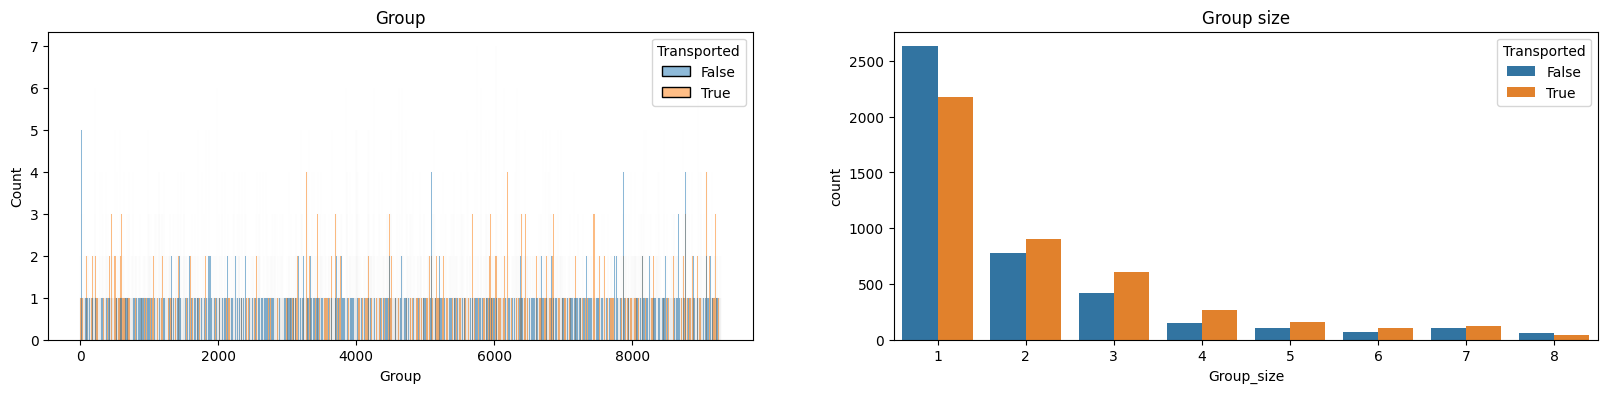

In [11]:
# 新增特征 组别
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)

# 新增特征 组的人数
train['Group_size']=train['Group'].map(lambda x: pd.concat([train['Group'], test['Group']]).value_counts()[x])
test['Group_size']=test['Group'].map(lambda x: pd.concat([train['Group'], test['Group']]).value_counts()[x])

plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.histplot(data=train, x='Group', hue='Transported', binwidth=1)
plt.title('Group')

plt.subplot(1,2,2)
sns.countplot(data=train, x='Group_size', hue='Transported')
plt.title('Group size')
fig.tight_layout()

#运行过慢

<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='Solo', ylabel='count'>

Text(0.5, 1.0, 'Passenger travelling solo or not')

(0.0, 3000.0)

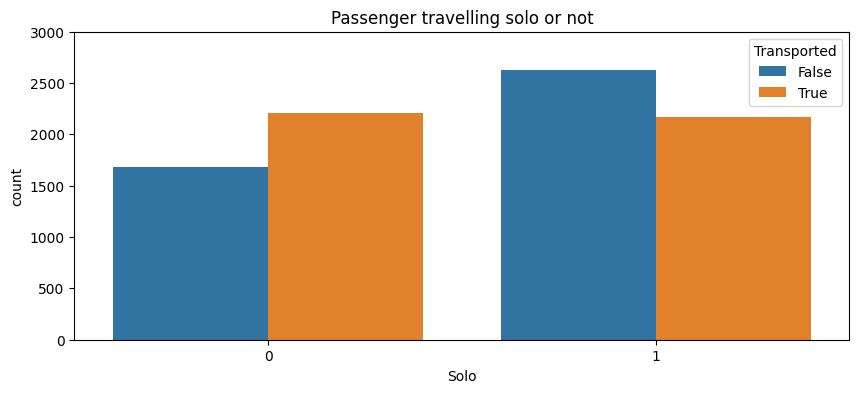

In [12]:
# 是否单人间
train['Solo']=(train['Group_size']==1).astype(int)
test['Solo']=(test['Group_size']==1).astype(int)

# New feature distribution
plt.figure(figsize=(10,4))
sns.countplot(data=train, x='Solo', hue='Transported')
plt.title('Passenger travelling solo or not')
plt.ylim([0,3000])

## 3.舱室

In [13]:
decks=train['Cabin'].dropna().apply(lambda x: x.split('/')[0])
decks.value_counts()

Cabin
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

将cabin拆分为三个字段：甲板、舱室号和舷侧

In [14]:
train['Cabin_deck'] = train['Cabin'].apply(lambda x: x.split('/')[0] if not pd.isna(x) else None)
train['Cabin_number'] = train['Cabin'].apply(lambda x: int(x.split('/')[1]) if not pd.isna(x) else None)
train['Cabin_side'] = train['Cabin'].apply(lambda x: x.split('/')[2] if not pd.isna(x) else None)

test['Cabin_deck'] = test['Cabin'].apply(lambda x: x.split('/')[0] if not pd.isna(x) else None)
test['Cabin_number'] = test['Cabin'].apply(lambda x: int(x.split('/')[1]) if not pd.isna(x) else None)
test['Cabin_side'] = test['Cabin'].apply(lambda x: x.split('/')[2] if not pd.isna(x) else None)

<Axes: >

<Axes: xlabel='Cabin_deck', ylabel='count'>

Text(0.5, 1.0, 'Cabin deck')

<Axes: >

<Axes: xlabel='Cabin_number', ylabel='Count'>

Text(0.5, 1.0, 'Cabin number')

(0.0, 2000.0)

<Axes: >

<Axes: xlabel='Cabin_side', ylabel='count'>

Text(0.5, 1.0, 'Cabin side')

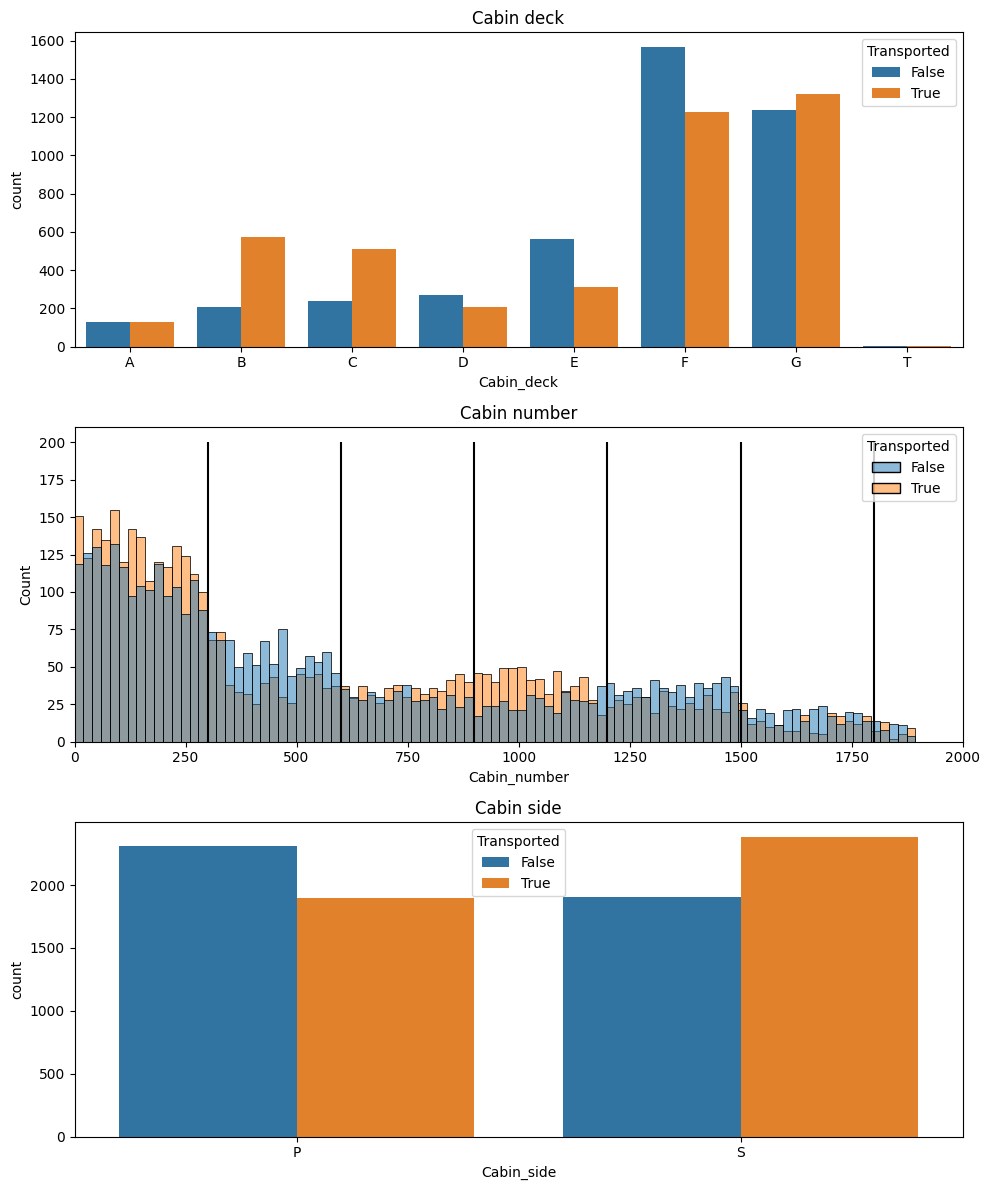

In [15]:
fig=plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
sns.countplot(data=train, x='Cabin_deck', hue='Transported', order=['A','B','C','D','E','F','G','T'])
plt.title('Cabin deck')

plt.subplot(3,1,2)
sns.histplot(data=train, x='Cabin_number', hue='Transported',binwidth=20)
plt.vlines(300, ymin=0, ymax=200, color='black')
plt.vlines(600, ymin=0, ymax=200, color='black')
plt.vlines(900, ymin=0, ymax=200, color='black')
plt.vlines(1200, ymin=0, ymax=200, color='black')
plt.vlines(1500, ymin=0, ymax=200, color='black')
plt.vlines(1800, ymin=0, ymax=200, color='black')
plt.title('Cabin number')
plt.xlim([0,2000])

plt.subplot(3,1,3)
sns.countplot(data=train, x='Cabin_side', hue='Transported')
plt.title('Cabin side')
fig.tight_layout()

# 3.家庭

In [16]:
# Replace NaN's with outliers for now (so we can split feature)
train['Name'].fillna('Unknown Unknown')
test['Name'].fillna('Unknown Unknown')

# New feature - Surname
train['Surname']=train['Name'].str.split().str[-1]
test['Surname']=test['Name'].str.split().str[-1]

0         Maham Ofracculy
1            Juanna Vines
2           Altark Susent
3            Solam Susent
4       Willy Santantines
              ...        
8688    Gravior Noxnuther
8689      Kurta Mondalley
8690         Fayey Connon
8691     Celeon Hontichre
8692     Propsh Hontichre
Name: Name, Length: 8693, dtype: object

0        Nelly Carsoning
1         Lerome Peckers
2        Sabih Unhearfus
3       Meratz Caltilter
4        Brence Harperez
              ...       
4272         Jeron Peter
4273       Matty Scheron
4274         Jayrin Pore
4275      Kitakan Conale
4276    Lilace Leonzaley
Name: Name, Length: 4277, dtype: object

In [18]:
# New feature - Family size
train.loc[train['Surname']=='Unknown', 'Surname'] = np.nan
test.loc[test['Surname']=='Unknown', 'Surname'] = np.nan

surname_count = train['Surname'].value_counts()
s = surname_count.add(test['Surname'].value_counts(),fill_value=0)

In [ ]:
s = s.rename('Family_Size')
train2 = pd.merge(train,s,how='left',on='Surname')
test2 = pd.merge(test,s,how='left',on='Surname')
#这里变成了train2防止改乱原数据集
# Put Nan's back in (we will fill these later)
train2.loc[train['Surname']=='Unknown',['Surname','Family_size']]=np.nan
test2.loc[test['Surname']=='Unknown',['Surname','Family_size']]=np.nan


# New feature distribution
plt.figure(figsize=(12,4))
sns.countplot(data=train2, x='Family_Size', hue='Transported')
plt.title('Family size')